In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Callable, Dict, List

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Лабораторная работа: Conditional Average Treatment Effect и Meta-Learners

## Цель

В этой работе нужно реализовать и сравнить три популярных мета-обучателя для оценки индивидуальных причинных эффектов:

- **S-Learner**
- **T-Learner**
- **X-Learner**

Мы будем работать на **синтетических данных**, где известны истинные потенциальные исходы и, следовательно, известен истинный эффект лечения:

$$
\tau(x) = \mu_1(x) - \mu_0(x).
$$

Это позволяет напрямую сравнивать качество оценок CATE.


## Что нужно сделать

1. Сгенерировать несколько синтетических датасетов.
2. Реализовать:
   - `SLearner`
   - `TLearner`
   - `XLearner`
3. Обучить модели.
4. Оценить качество на тестовой выборке по метрикам:
   - **MSE для CATE** (т.н. **PEHE**)
   - абсолютное отклонение **ATE**
5. Сравнить методы на нескольких датасетах и сделать выводы.

## Теория

Обозначения:

- $X$ — признаки объекта
- $W \in \{0,1\}$ — индикатор лечения
- $Y_0$ — потенциальный исход без лечения
- $Y_1$ — потенциальный исход с лечением
- наблюдаемый исход:

$$
Y = W \cdot Y_1 + (1-W)\cdot Y_0
$$

- условный средний эффект лечения:

$$
\tau(x) = \mathbb{E}[Y_1 - Y_0\mid X=x]
$$




## Генерация синтетических данных

Ниже мы создадим несколько сценариев, в каждом из которых известно истинное значение $\tau(x)$.

### Интерфейс синтетического датасета

In [2]:
@dataclass
class SyntheticDataset:
    name: str
    X: np.ndarray
    w: np.ndarray
    y: np.ndarray
    y0: np.ndarray
    y1: np.ndarray
    tau: np.ndarray
    e: np.ndarray  # propensity score


## Датасет 1: линейный гетерогенный эффект

Идея:
- базовый исход $\mu_0(x)$ линейно зависит от признаков;
- эффект лечения $\tau(x)$ тоже линейный, но зависит от признаков иначе;
- назначение лечения зависит от $X$, то есть есть т.н. искажающие факторы (confounders).


In [3]:
def make_dataset_linear(n=3000, p=5, noise_std=1.0, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))

    mu0 = (
        1.0
        + 1.5 * X[:, 0]
        - 1.0 * X[:, 1]
        + 0.5 * X[:, 2]
    )

    tau = 1.0 + 0.8 * X[:, 0] - 0.6 * X[:, 1]

    mu1 = mu0 + tau

    logits = 0.3 * X[:, 0] - 0.2 * X[:, 1] + 0.1 * X[:, 2]
    e = 1 / (1 + np.exp(-logits))
    e = np.clip(e, 0.05, 0.95)

    w = rng.binomial(1, e)
    y0 = mu0 + rng.normal(scale=noise_std, size=n)
    y1 = mu1 + rng.normal(scale=noise_std, size=n)
    y = np.where(w == 1, y1, y0)

    return SyntheticDataset(
        name="linear_cate",
        X=X, w=w, y=y, y0=y0, y1=y1, tau=tau, e=e
    )


## Датасет 2: нелинейный гладкий эффект

Здесь CATE – гладкая нелинейная функция признаков.

In [4]:
def make_dataset_nonlinear(n=3000, p=5, noise_std=1.0, seed=43):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, size=(n, p))

    mu0 = (
        2.0
        + np.sin(np.pi * X[:, 0])
        + 0.5 * X[:, 1] ** 2
        - 0.5 * X[:, 2]
    )

    tau = (
        1.5 * np.sin(X[:, 0] * X[:, 1])
        + 0.5 * (X[:, 2] > 0).astype(float)
        - 0.3 * X[:, 3] ** 2
    )

    mu1 = mu0 + tau

    logits = -0.1 + 0.5 * X[:, 0] - 0.4 * X[:, 1] + 0.2 * X[:, 3]
    e = 1 / (1 + np.exp(-logits))
    e = np.clip(e, 0.05, 0.95)

    w = rng.binomial(1, e)
    y0 = mu0 + rng.normal(scale=noise_std, size=n)
    y1 = mu1 + rng.normal(scale=noise_std, size=n)
    y = np.where(w == 1, y1, y0)

    return SyntheticDataset(
        name="nonlinear_cate",
        X=X, w=w, y=y, y0=y0, y1=y1, tau=tau, e=e
    )

## Датасет 3: сегментный эффект

В этом сценарии эффект отличается между подгруппами.

In [5]:
def make_dataset_piecewise(n=3000, p=6, noise_std=1.0, seed=44):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))

    mu0 = (
        -1.0
        + 0.7 * X[:, 0]
        + 0.5 * X[:, 1]
        - 0.8 * X[:, 2]
        + 0.2 * X[:, 3] ** 2
    )

    tau = (
        2.0 * (X[:, 0] > 0).astype(float)
        - 1.5 * (X[:, 1] > 0.5).astype(float)
        + 0.7 * (X[:, 2] < -0.5).astype(float)
    )

    mu1 = mu0 + tau

    logits = 0.2 + 0.7 * (X[:, 0] > 0).astype(float) - 0.5 * X[:, 2]
    e = 1 / (1 + np.exp(-logits))
    e = np.clip(e, 0.05, 0.95)

    w = rng.binomial(1, e)
    y0 = mu0 + rng.normal(scale=noise_std, size=n)
    y1 = mu1 + rng.normal(scale=noise_std, size=n)
    y = np.where(w == 1, y1, y0)

    return SyntheticDataset(
        name="piecewise_cate",
        X=X, w=w, y=y, y0=y0, y1=y1, tau=tau, e=e
    )

## Соберём все датасеты

In [6]:
datasets = [
    make_dataset_linear(),
    make_dataset_nonlinear(),
    make_dataset_piecewise(),
]

for ds in datasets:
    print(f'{ds.name:15} {ds.X.shape}, {ds.w.mean():.3f}, {ds.tau.mean():.3f}')

linear_cate     (3000, 5), 0.493, 0.973
nonlinear_cate  (3000, 5), 0.475, -0.171
piecewise_cate  (3000, 6), 0.619, 0.738


Распределения истинного эффекта:

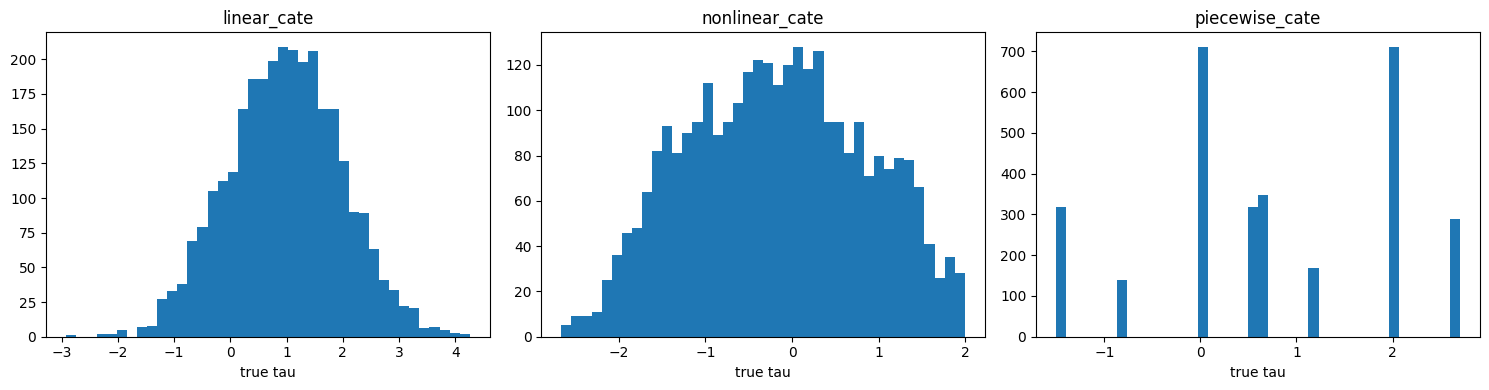

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ds in zip(axes, datasets):
    ax.hist(ds.tau, bins=40)
    ax.set_title(ds.name)
    ax.set_xlabel("true tau")
plt.tight_layout()
plt.show()

## Полезные метрики

### PEHE

PEHE (Precision in Estimation of Heterogeneous Effect) – просто RMSE по эффекту:

$$
\text{PEHE} = \sqrt{\mathbb{E}\left[(\hat\tau(X)-\tau(X))^2\right]}
$$

### Абсолютное отклонение ATE

$$
\text{AbsErr} = \lvert \mathbb{E}[\hat\tau(X)] - \mathbb{E}[\tau(X)] \rvert
$$

In [8]:
def cate_mse(tau_true, tau_pred):
    return np.mean((tau_true - tau_pred) ** 2)


def pehe(tau_true, tau_pred):
    return np.sqrt(cate_mse(tau_true, tau_pred))


def ate_error(tau_true, tau_pred):
    return abs(np.mean(tau_true) - np.mean(tau_pred))


## Базовые модели

Для простоты будем использовать `RandomForestRegressor`.

In [9]:
def make_base_regressor(random_state=0):
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=10,
        random_state=random_state,
        n_jobs=-1,
    )


def make_propensity_model():
    return LogisticRegression(max_iter=1000)


## Реализация S-Learner

Идея:
- обучаем одну модель $\hat\mu(x, w)$, куда индикатор лечения подаётся как дополнительный признак;
- затем:
  - $\hat\mu_1(x) = \hat\mu(x, 1)$
  - $\hat\mu_0(x) = \hat\mu(x, 0)$
- оценка эффекта:
$$
\hat\tau(x)=\hat\mu_1(x)-\hat\mu_0(x)
$$

In [39]:
class SLearner:
    def __init__(self, base_model):
        self.model = clone(base_model)

    @staticmethod
    def _add_treatment_feature(X, w_value):
        X = np.asarray(X)
        w_col = np.full((X.shape[0], 1), w_value, dtype=float)
        return np.hstack([X, w_col])

    def fit(self, X, w, y):
        X = np.asarray(X)
        w = np.asarray(w).reshape(-1, 1)
        X_aug = np.hstack([X, w])
        self.model.fit(X_aug, y)
        return self

    def predict_mu0(self, X):
        return self.model.predict(self._add_treatment_feature(X, 0.0))

    def predict_mu1(self, X):
        return self.model.predict(self._add_treatment_feature(X, 1.0))

    def predict_tau(self, X):
        return self.predict_mu1(X) - self.predict_mu0(X)


## Реализация T-Learner

Идея:
- обучаем две отдельные модели:
  - $\hat\mu_0(x)$ по контрольной группе,
  - $\hat\mu_1(x)$ по леченной группе.
- затем:
$$
\hat\tau(x)=\hat\mu_1(x)-\hat\mu_0(x)
$$

In [62]:
class TLearner:
    def __init__(self, base_model):
        self.model_treated = clone(base_model)
        self.model_control = clone(base_model)

    def fit(self, X, w, y):
        X = np.asarray(X)
        w = np.asarray(w)
        y = np.asarray(y)

        treated_mask = (w == 1)
        control_mask = (w == 0)

        self.model_treated.fit(X[treated_mask], y[treated_mask])
        self.model_control.fit(X[control_mask], y[control_mask])
        return self

    def predict_mu0(self, X):
        return self.model_control.predict(X)

    def predict_mu1(self, X):
        return self.model_treated.predict(X)

    def predict_tau(self, X):
        return self.predict_mu1(X) - self.predict_mu0(X)

## Реализация X-Learner

Схема X-Learner:

1. Обучить модели исходов:
   - $\hat\mu_0(x)$
   - $\hat\mu_1(x)$

2. Построить псевдо-эффекты:
   - для леченных:
$$
D^1 = Y - \hat\mu_0(X)
$$
   - для контрольных:
$$
D^0 = \hat\mu_1(X) - Y
$$

3. Обучить две модели эффектов:
   - $\hat\tau_1(x)$ по леченным на $D^1$
   - $\hat\tau_0(x)$ по контрольным на $D^0$

4. Скомбинировать:
$$
\hat\tau(x) = g(x)\hat\tau_0(x) + (1-g(x))\hat\tau_1(x)
$$
где $g(x)$ — propensity score.

In [80]:
class XLearner:
    def __init__(self, outcome_model, effect_model=None, propensity_model=None):
        self.mu0_model = clone(outcome_model)
        self.mu1_model = clone(outcome_model)

        if effect_model is None:
            effect_model = outcome_model
        self.tau0_model = clone(effect_model)
        self.tau1_model = clone(effect_model)

        self.propensity_model = propensity_model if propensity_model is not None else make_propensity_model()

    def fit(self, X, w, y):
        X = np.asarray(X)
        w = np.asarray(w)
        y = np.asarray(y)

        treated_mask = (w == 1)
        control_mask = (w == 0)

        X_treated, y_treated = X[treated_mask], y[treated_mask]
        X_control, y_control = X[control_mask], y[control_mask]

        self.mu0_model.fit(X_control, y_control)
        self.mu1_model.fit(X_treated, y_treated)

        d1 = y_treated - self.mu0_model.predict(X_treated)
        d0 = self.mu1_model.predict(X_control) - y_control

        self.tau1_model.fit(X_treated, d1)
        self.tau0_model.fit(X_control, d0)

        self.propensity_model.fit(X, w)

        return self

    def predict_propensity(self, X):
        g = self.propensity_model.predict_proba(X)[:, 1]
        return np.clip(g, 1e-3, 1 - 1e-3)

    def predict_mu0(self, X):
        return self.mu0_model.predict(X)

    def predict_mu1(self, X):
        return self.mu1_model.predict(X)

    def predict_tau(self, X):
        g = self.predict_propensity(X)
        tau0 = self.tau0_model.predict(X)
        tau1 = self.tau1_model.predict(X)
        return g * tau0 + (1 - g) * tau1


## Единый интерфейс для экспериментов

In [81]:

ds_smoke = make_dataset_linear(n=1200, seed=123)
idx = np.arange(len(ds_smoke.y))
idx_train, idx_test = train_test_split(idx, test_size=0.3, random_state=123)

X_train, w_train, y_train = ds_smoke.X[idx_train], ds_smoke.w[idx_train], ds_smoke.y[idx_train]
X_test, tau_test = ds_smoke.X[idx_test], ds_smoke.tau[idx_test]

base_smoke = make_base_regressor(random_state=123)
learners_smoke = {
    "S-Learner": SLearner(base_smoke),
    "T-Learner": TLearner(base_smoke),
    "X-Learner": XLearner(base_smoke, propensity_model=make_propensity_model()),
}

for name, learner in learners_smoke.items():
    learner.fit(X_train, w_train, y_train)
    tau_hat = learner.predict_tau(X_test)
    print(
        f"{name:10} | tau_hat shape={tau_hat.shape} | "
        f"PEHE={pehe(tau_test, tau_hat):.4f} | "
        f"ATE err={ate_error(tau_test, tau_hat):.4f}"
    )

S-Learner  | tau_hat shape=(360,) | PEHE=0.4251 | ATE err=0.0581
T-Learner  | tau_hat shape=(360,) | PEHE=0.5969 | ATE err=0.2083
X-Learner  | tau_hat shape=(360,) | PEHE=0.3757 | ATE err=0.1116


In [82]:
def get_learners(random_state=0):
    base = make_base_regressor(random_state=random_state)
    return {
        "S-Learner": SLearner(base),
        "T-Learner": TLearner(base),
        "X-Learner": XLearner(base, propensity_model=make_propensity_model()),
    }


## Разделение на train/test

In [83]:
def train_test_split_synthetic(ds, test_size=0.3, random_state=0):
    idx = np.arange(len(ds.y))
    idx_train, idx_test = train_test_split(
        idx, test_size=test_size, random_state=random_state
    )

    train = {
        "X": ds.X[idx_train],
        "w": ds.w[idx_train],
        "y": ds.y[idx_train],
        "tau": ds.tau[idx_train],
    }
    test = {
        "X": ds.X[idx_test],
        "w": ds.w[idx_test],
        "y": ds.y[idx_test],
        "tau": ds.tau[idx_test],
    }
    return train, test


## Запуск одного эксперимента

In [84]:
def evaluate_learners_on_dataset(ds, random_state=0):
    train, test = train_test_split_synthetic(ds, random_state=random_state)
    learners = get_learners(random_state=random_state)

    rows = []
    preds = {}

    for name, learner in learners.items():
        learner.fit(train["X"], train["w"], train["y"])
        tau_hat = learner.predict_tau(test["X"])
        preds[name] = tau_hat

        rows.append({
            "dataset": ds.name,
            "learner": name,
            "cate_mse": cate_mse(test["tau"], tau_hat),
            "pehe": pehe(test["tau"], tau_hat),
            "ate_error": ate_error(test["tau"], tau_hat),
        })

    return pd.DataFrame(rows), test["tau"], preds


## Сравнение на одном прогоне

In [85]:
all_results = []
all_predictions = {}

for ds in datasets:
    result_df, tau_true, preds = evaluate_learners_on_dataset(ds, random_state=0)
    all_results.append(result_df)
    all_predictions[ds.name] = (tau_true, preds)

results_df = pd.concat(all_results, ignore_index=True)
results_df

,dataset,learner,cate_mse,pehe,ate_error
0,linear_cate,S-Learner,0.214489,0.463130,0.071843
1,linear_cate,T-Learner,0.238038,0.487892,0.170523
2,linear_cate,X-Learner,0.094099,0.306756,0.107239
3,nonlinear_cate,S-Learner,0.936426,0.967691,0.198939
4,nonlinear_cate,T-Learner,0.347118,0.589167,0.034144
5,nonlinear_cate,X-Learner,0.298838,0.546661,0.001634
6,piecewise_cate,S-Learner,0.426402,0.652994,0.083128
7,piecewise_cate,T-Learner,0.261072,0.510952,0.001121
8,piecewise_cate,X-Learner,0.100182,0.316515,0.060548


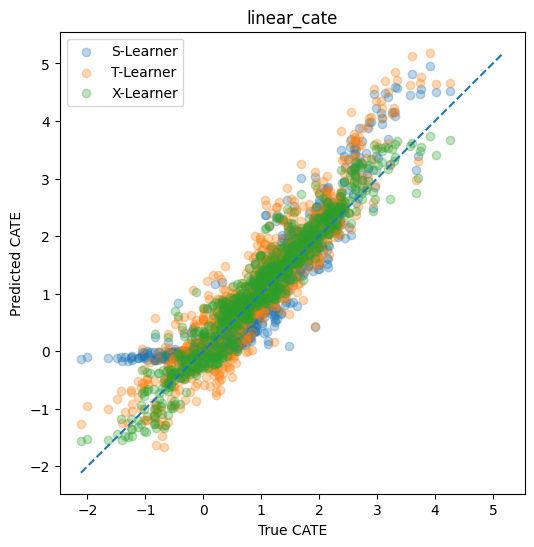

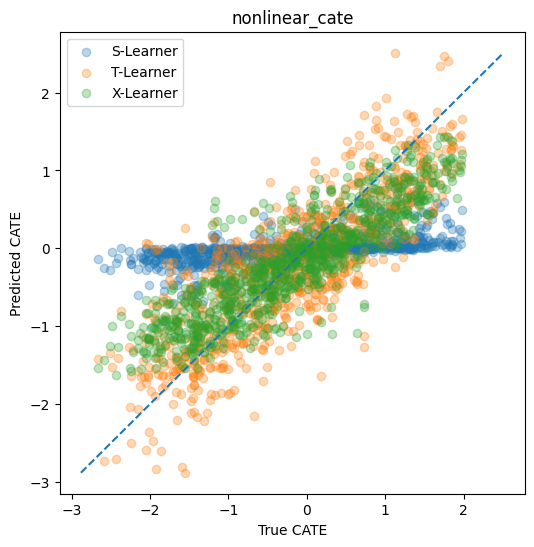

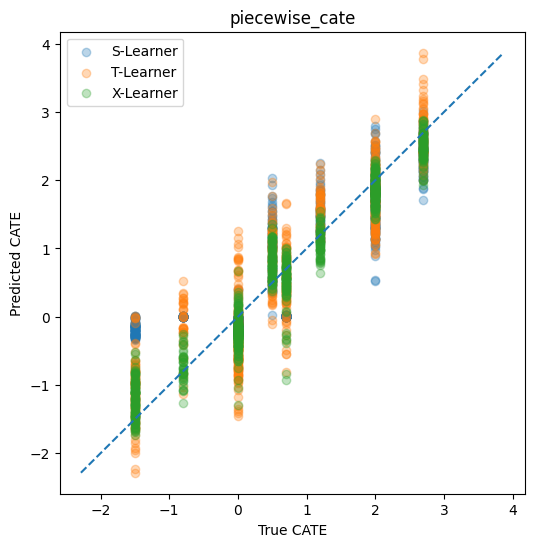

In [86]:
for ds_name, (tau_true, preds) in all_predictions.items():
    plt.figure(figsize=(6, 6))
    plt.scatter(tau_true, preds["S-Learner"], alpha=0.3, label="S-Learner")
    plt.scatter(tau_true, preds["T-Learner"], alpha=0.3, label="T-Learner")
    plt.scatter(tau_true, preds["X-Learner"], alpha=0.3, label="X-Learner")
    mn = min(tau_true.min(), *(v.min() for v in preds.values()))
    mx = max(tau_true.max(), *(v.max() for v in preds.values()))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("True CATE")
    plt.ylabel("Predicted CATE")
    plt.title(ds_name)
    plt.legend()
    plt.show()


## Усреднение по нескольким random seed

Чтобы сравнение было более адекватным, повторим эксперимент несколько раз.

In [87]:
def run_benchmark(datasets, seeds=range(5)):
    all_rows = []

    for seed in seeds:
        for ds in datasets:
            result_df, _, _ = evaluate_learners_on_dataset(ds, random_state=seed)
            result_df["seed"] = seed
            all_rows.append(result_df)

    return pd.concat(all_rows, ignore_index=True)

benchmark_df = run_benchmark(datasets, seeds=range(5))
benchmark_df.head()

,dataset,learner,cate_mse,pehe,ate_error,seed
0,linear_cate,S-Learner,0.214489,0.463130,0.071843,0
1,linear_cate,T-Learner,0.238038,0.487892,0.170523,0
2,linear_cate,X-Learner,0.094099,0.306756,0.107239,0
3,nonlinear_cate,S-Learner,0.936426,0.967691,0.198939,0
4,nonlinear_cate,T-Learner,0.347118,0.589167,0.034144,0


In [88]:
summary = (
    benchmark_df
    .groupby(["dataset", "learner"], as_index=False)
    [["cate_mse", "pehe", "ate_error"]]
    .mean()
    .sort_values(["dataset", "pehe"])
)

summary

,dataset,learner,cate_mse,pehe,ate_error
2,linear_cate,X-Learner,0.109149,0.329372,0.062656
0,linear_cate,S-Learner,0.230873,0.480285,0.052213
1,linear_cate,T-Learner,0.256858,0.505861,0.083200
5,nonlinear_cate,X-Learner,0.359832,0.598910,0.049317
4,nonlinear_cate,T-Learner,0.411175,0.639835,0.037356
3,nonlinear_cate,S-Learner,0.853991,0.923708,0.161203
8,piecewise_cate,X-Learner,0.120061,0.345755,0.044341
7,piecewise_cate,T-Learner,0.298036,0.545189,0.019595
6,piecewise_cate,S-Learner,0.428281,0.653961,0.043641


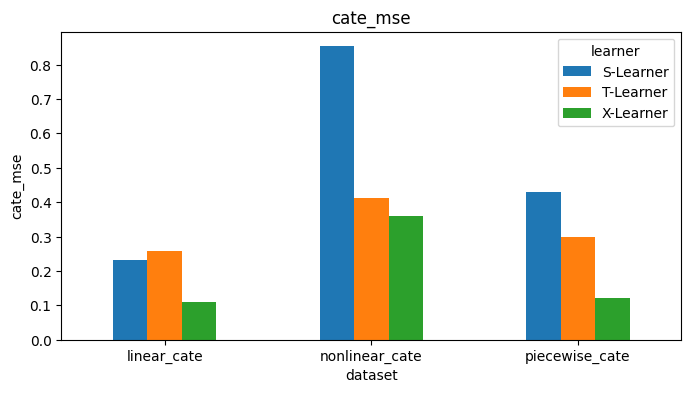

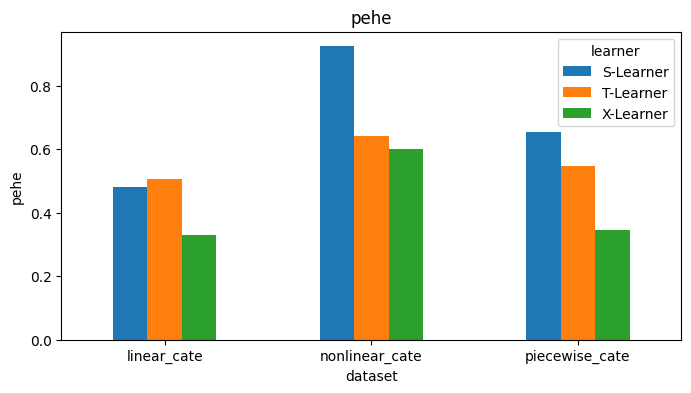

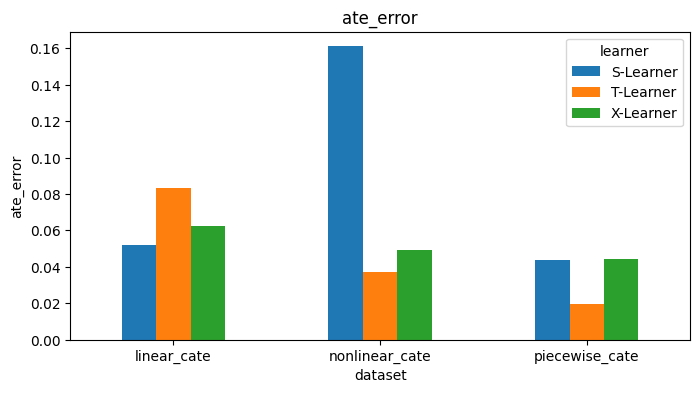

In [90]:
for metric in ["cate_mse", "pehe", "ate_error"]:
    pivot = summary.pivot(index="dataset", columns="learner", values=metric)
    pivot.plot(kind="bar", figsize=(8, 4), title=metric)
    plt.ylabel(metric)
    plt.xticks(rotation=0)
    plt.show()

# Дополнительные задания 🌟

1. Ниже сгенерируйте датасет, на котором X-Learner будет работать хуже, чем S- и/или T-Learner (с точки зрения PEHE).
2. Почему абсолютное отклонение ATE может быть меньше у одной модели, а PEHE – у другой?
3. Как сделать проведение экспериментов (бенчмарк) более корректно?

*Сохраняйте адекватную долю контрольной группы (контрольная группа всегда значительно больше лечебной).*

In [92]:
def make_dataset_xlearner_hard(n=3500, p=6, noise_std=1.2, seed=2026):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))

    mu0 = (
        1.5
        + 1.2 * X[:, 0]
        - 1.0 * X[:, 1]
        + 0.8 * np.sin(1.5 * X[:, 2])
        + 0.5 * X[:, 3] ** 2
    )

    tau = 0.9 + 0.15 * X[:, 0]
    mu1 = mu0 + tau

    logits = -2.5 + 0.3 * X[:, 0] - 0.2 * X[:, 1]
    e = 1 / (1 + np.exp(-logits))
    e = np.clip(e, 0.02, 0.20)

    w = rng.binomial(1, e)
    y0 = mu0 + rng.normal(scale=noise_std, size=n)
    y1 = mu1 + rng.normal(scale=noise_std, size=n)
    y = np.where(w == 1, y1, y0)

    return SyntheticDataset(
        name="xlearner_hard",
        X=X, w=w, y=y, y0=y0, y1=y1, tau=tau, e=e
    )


hard_ds = make_dataset_xlearner_hard()
print(f"treated share: {hard_ds.w.mean():.3f} | control share: {(1-hard_ds.w.mean()):.3f}")

hard_result_df, _, _ = evaluate_learners_on_dataset(hard_ds, random_state=7)
hard_result_df.sort_values("pehe")

treated share: 0.073 | control share: 0.927


,dataset,learner,cate_mse,pehe,ate_error
2,xlearner_hard,X-Learner,0.254287,0.504269,0.003274
1,xlearner_hard,T-Learner,0.588131,0.766897,0.072669
0,xlearner_hard,S-Learner,0.797563,0.893064,0.881597


`ATE error` оценивает только средний эффект по всей выборке**. Модель может ошибаться на многих объектах, но ошибки разного знака взаимно компенсируются — тогда среднее близко к истине, и ATE error маленький.

`PEHE` оценивает индивидуальные ошибки CATE. Даже при хорошем среднем эффекте модель может плохо восстанавливать гетерогенность между объектами, и тогда PEHE будет большим.

Итог: маленький ATE error не гарантирует хорошее качество индивидуальных эффектов.

## Как сделать проведение экспериментов (бенчмарк) более корректно?

- Использовать больше `seed'ов` и сравнивать не только среднее, но и std и квантиль.
- Валидировать гиперпараметры, а не держать их фиксированными по умолчанию.
- Добавить больше сценариев: разная сила шума, степень нелинейности, уровень дисбаланса treatment/control, разные propensity-функции.
- Проверять overlap, исключать слишком экстремальные propensity и анализировать чувствительность к плохому overlap.
- Сравнивать не только RandomForest, но и несколько базовых моделей (линейные/бустинг), чтобы выводы не зависели от одного конкретного learner backbone.

In [95]:
# Данное решение предложено ллмой выглядит не оч, но так может от рандома избавимся и гарантировано получим ситуацию 
def make_dataset_xlearner_search(seed, n=1600, p=6):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))

    mu0 = (
        -0.56
        + 1.37 * X[:, 0]
        - 0.83 * X[:, 1]
        + 0.41 * np.sin(2.57 * X[:, 2])
        + 0.65 * X[:, 3] ** 2
    )

    tau = 0.82 + 0.07 * X[:, 0] + 0.31 * np.sin(1.06 * X[:, 0] * X[:, 1])
    mu1 = mu0 + tau

    logits = (
        -2.57
        + 1.73 * np.sin(2 * X[:, 0])
        - 0.53 * (X[:, 1] > 0).astype(float)
        + 0.99 * X[:, 2] * X[:, 3]
    )
    e = 1 / (1 + np.exp(-logits))
    e = np.clip(e, 0.01, 0.35)

    w = rng.binomial(1, e)
    y0 = mu0 + rng.normal(scale=2.15, size=n)
    y1 = mu1 + rng.normal(scale=2.15, size=n)
    y = np.where(w == 1, y1, y0)

    return SyntheticDataset(
        name="xlearner_worse_case",
        X=X, w=w, y=y, y0=y0, y1=y1, tau=tau, e=e,
    )


found = None
max_tries = 80

for seed in range(max_tries):
    ds = make_dataset_xlearner_search(seed=seed)

    if ds.w.mean() >= 0.20:
        continue

    result_df, _, _ = evaluate_learners_on_dataset(ds, random_state=0)
    pehe_map = result_df.set_index("learner")["pehe"].to_dict()

    x_pehe = pehe_map["X-Learner"]
    if x_pehe > pehe_map["S-Learner"] or x_pehe > pehe_map["T-Learner"]:
        found = (seed, ds.w.mean(), result_df.sort_values("pehe"))
        break

if found is None:
    print("Не нашли seed за max_tries; увеличьте max_tries до 150-200.")
else:
    best_seed, treated_share, table = found
    print(f"Found seed={best_seed}, treated share={treated_share:.3f}, control share={1-treated_share:.3f}")
    table

Found seed=2, treated share=0.099, control share=0.901
